In [1]:
import os
import re
import pickle
import zipfile
import urllib.request
from collections import Counter
import pickle
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt 
from PIL import Image
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import (
    Input, Dense, LSTM, Embedding, Dropout,
    Concatenate, RepeatVector, Permute,
    Multiply, Flatten, Activation, Lambda
)
from tensorflow.keras.models import Model


GLOVE_ZIP = "glove.6B.zip"
GLOVE_FILE = "glove.6B.200d.txt"

if not os.path.exists(GLOVE_ZIP):
    print("Downloading GloVe...")
    urllib.request.urlretrieve(
        "https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip",
        GLOVE_ZIP
    )

if not os.path.exists(GLOVE_FILE):
    print("Extracting GloVe...")
    with zipfile.ZipFile(GLOVE_ZIP, "r") as z:
        z.extract(GLOVE_FILE)

print("GloVe ready!")

2026-04-26 11:10:22.502076: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777201822.743238      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777201822.811497      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777201823.334253      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777201823.334296      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777201823.334299      55 computation_placer.cc:177] computation placer alr

Extracting GloVe...
GloVe ready!


In [2]:
with open("/kaggle/input/datasets/adityajn105/flickr8k/captions.txt", "r") as f:
    captions_raw = f.readlines()


print("Total lines:", len(captions_raw))


for line in captions_raw[:5]:
    print(line.strip())

Total lines: 40456
image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .


In [3]:

def clean_caption(caption):
    caption = caption.lower()
    caption = re.sub(r"[^a-z\s]", "", caption)
    caption = caption.strip()
    caption = "startseq " + caption + " endseq"
    return caption


captions_dict = {}

for line in captions_raw[1:]:  
    line = line.strip()
    if not line:
        continue
    img_name, caption = line.split(",", 1)
    cleaned = clean_caption(caption)
    if img_name not in captions_dict:
        captions_dict[img_name] = []
    captions_dict[img_name].append(cleaned)

# Verify
print("Total images:", len(captions_dict))
print("\nSample image:", list(captions_dict.keys())[0])
print("Its captions:")
for c in list(captions_dict.values())[0]:
    print(" ", c)

Total images: 8091

Sample image: 1000268201_693b08cb0e.jpg
Its captions:
  startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq
  startseq a girl going into a wooden building endseq
  startseq a little girl climbing into a wooden playhouse endseq
  startseq a little girl climbing the stairs to her playhouse endseq
  startseq a little girl in a pink dress going into a wooden cabin endseq


In [4]:

all_words = []
for captions in captions_dict.values():
    for caption in captions:
        all_words.extend(caption.split())


word_counts = Counter(all_words)
print("Total unique words:", len(word_counts))


vocab = [word for word, count in word_counts.items() if count >= 5]
print("Vocabulary size after filtering:", len(vocab))


word_to_idx = {word: idx+1 for idx, word in enumerate(vocab)}
idx_to_word = {idx+1: word for idx, word in enumerate(vocab)}

vocab_size = len(vocab) + 1  
print("Final vocab size:", vocab_size)


all_captions_flat = [c for caps in captions_dict.values() for c in caps]
max_len = max(len(c.split()) for c in all_captions_flat)
print("Max caption length:", max_len)

Total unique words: 8780
Vocabulary size after filtering: 2986
Final vocab size: 2987
Max caption length: 37


In [5]:
all_images = list(captions_dict.keys())
print("Total images:", len(all_images))


np.random.seed(42)  
np.random.shuffle(all_images)

split = int(0.9 * len(all_images))
train_images = all_images[:split]
test_images  = all_images[split:]

train_captions = {img: captions_dict[img] for img in train_images}
test_captions  = {img: captions_dict[img] for img in test_images}

print("Train images:", len(train_captions))
print("Test images: ", len(test_captions))

Total images: 8091
Train images: 7281
Test images:  810


In [6]:

base_model = InceptionV3(weights='imagenet')
cnn_model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
print("InceptionV3 loaded. Output shape:", cnn_model.output_shape)


img_dir = "/kaggle/input/datasets/adityajn105/flickr8k/Images"

features = {}
all_img_names = list(captions_dict.keys())

for img_name in tqdm(all_img_names, desc="Extracting features"):
    img_path = os.path.join(img_dir, img_name)
    try:
        img = load_img(img_path, target_size=(299, 299))
        img = img_to_array(img)
        img = preprocess_input(img)
        img = np.expand_dims(img, axis=0)
        feature = cnn_model.predict(img, verbose=0)
        features[img_name] = feature
    except Exception as e:
        print(f"Skipped {img_name}: {e}")

print("Done! Total features extracted:", len(features))


pickle.dump(features, open("features.pkl", "wb"))
print("Features saved to features.pkl")

I0000 00:00:1777202015.057853      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777202015.064010      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
InceptionV3 loaded. Output shape: (None, 2048)


Extracting features:   0%|          | 0/8091 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1777202020.913914     142 service.cc:152] XLA service 0x7cb6a80018e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777202020.913954     142 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777202020.913958     142 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777202022.164479     142 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777202027.230947     142 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Extracting features: 100%|██████████| 8091/8091 [15:29<00:00,  8.71it/s]


Done! Total features extracted: 8091
Features saved to features.pkl


In [7]:
# Load GloVe 200d vectors
glove = {}
with open("glove.6B.200d.txt", encoding="utf-8") as f:
    for line in f:
        parts = line.split()
        word  = parts[0]
        vec   = np.array(parts[1:], dtype="float32")
        glove[word] = vec

print(f"GloVe loaded: {len(glove)} words")


EMBED_DIM = 200  # ← changed from 256 to 200
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
matched = 0

for word, idx in word_to_idx.items():
    vec = glove.get(word)
    if vec is not None:
        embedding_matrix[idx] = vec
        matched += 1

print(f"Vocab words matched in GloVe: {matched}/{len(word_to_idx)}")

GloVe loaded: 400000 words
Vocab words matched in GloVe: 2948/2986


In [8]:
def build_model_v2(vocab_size, max_len, embedding_matrix):
    EMBED_DIM  = 200
    LSTM_UNITS = 256

    # ── Image branch ──────────────────────────────────────────
    img_input    = Input(shape=(2048,), name="image_input")
    img_dense    = Dense(EMBED_DIM, activation='relu')(img_input)
    img_drop     = Dropout(0.3)(img_dense)
    img_repeated = RepeatVector(max_len)(img_drop) 

    # ── Text branch ───────────────────────────────────────────
    seq_input = Input(shape=(max_len,), name="seq_input")
    seq_embed = Embedding(
        vocab_size, EMBED_DIM,
        weights=[embedding_matrix],
        trainable=True,
        mask_zero=False
    )(seq_input)
    seq_drop = Dropout(0.2)(seq_embed)

    # ── Fusion ────────────────────────────────────────────────
    merged = Concatenate(axis=-1)([img_repeated, seq_drop]) 

    # ── Stacked LSTMs ─────────────────────────────────────────
    lstm1 = LSTM(LSTM_UNITS, return_sequences=True, use_cudnn=False)(merged)
    lstm1 = Dropout(0.3)(lstm1)
    lstm2 = LSTM(LSTM_UNITS, return_sequences=True, use_cudnn=False)(lstm1)
    # lstm2 shape: (batch, max_len, 512)

    # ── Bahdanau Attention────────────────────────────
    attn_hidden = Dense(128, activation='tanh')(lstm2)  
    attn_score  = Dense(1)(attn_hidden)             
    attn_score  = Flatten()(attn_score)                
    attn_weight = Activation('softmax')(attn_score)      
    attn_weight = tf.keras.layers.Reshape((1, max_len))(attn_weight) 

    # Weighted sum of LSTM outputs
    context = tf.keras.layers.Dot(axes=[2, 1])([attn_weight, lstm2])
    context = Flatten()(context)                               
    
    # ── Output ────────────────────────────────────────────────
    out_drop = Dropout(0.3)(context)
    output   = Dense(vocab_size, activation='softmax')(out_drop)

    model = Model(inputs=[img_input, seq_input], outputs=output)
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3)
    )
    return model
model_v2 = build_model_v2(vocab_size, max_len, embedding_matrix)
model_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 200)       │    409,800 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_input           │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 200)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 37, 200)   │    597,400 │ seq_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 37, 200)   │          0 │ dropout[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 37, 200)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 37, 400)   │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 37, 256)   │    672,768 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 37, 256)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 37, 256)   │    525,312 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 37, 128)   │     32,896 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 37, 1)     │        129 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 37)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 37)        │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 37)     │          0 │ activation_94[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1, 256)    │          0 │ reshape[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 256)       │          0 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 256)       │          0 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2987)      │    767,659 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,005,964 (11.47 MB)

 Trainable params: 3,005,964 (11.47 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def data_generator_flat(captions_dict, features, word_to_idx, max_len, vocab_size):
    img_names = list(captions_dict.keys())
    while True:
        for img_name in img_names:
            feature = features[img_name][0]
            for caption in captions_dict[img_name]:
                seq = [word_to_idx.get(w, 0) for w in caption.split()]
                for i in range(1, len(seq)):
                    in_seq   = pad_sequences([seq[:i]], maxlen=max_len)[0]
                    out_word = to_categorical([seq[i]], num_classes=vocab_size)[0]
                    yield (feature, in_seq), out_word

# Stats
total_samples = sum(
    len(caption.split()) - 1
    for caps in train_captions.values()
    for caption in caps
)


print("Total training samples:", total_samples)

Total training samples: 429610


In [10]:
BATCH_SIZE      = 64
STEPS_PER_EPOCH = 6000

dataset_v2 = tf.data.Dataset.from_generator(
    lambda: data_generator_flat(train_captions, features, word_to_idx, max_len, vocab_size),
    output_signature=(
        (
            tf.TensorSpec(shape=(2048,), dtype=tf.float32),
            tf.TensorSpec(shape=(max_len,), dtype=tf.int32)
        ),
        tf.TensorSpec(shape=(vocab_size,), dtype=tf.float32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

callbacks_v2 = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_model_v2.keras", monitor='loss', save_best_only=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1
    )
]

history_v2 = model_v2.fit(
    dataset_v2,
    epochs=20,             
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=callbacks_v2,
    verbose=1
)



Epoch 1/20
5999/6000 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 5.0541
Epoch 1: loss improved from inf to 4.50332, saving model to best_model_v2.keras
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 194s 31ms/step - loss: 5.0539 - learning_rate: 0.0010
Epoch 2/20
5999/6000 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.5311
Epoch 2: loss improved from 4.50332 to 3.45266, saving model to best_model_v2.keras
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 185s 31ms/step - loss: 3.5311 - learning_rate: 0.0010
Epoch 3/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.2478
Epoch 3: loss improved from 3.45266 to 3.21340, saving model to best_model_v2.keras
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 185s 31ms/step - loss: 3.2478 - learning_rate: 0.0010
Epoch 4/20
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.1288
Epoch 4: loss improved from 3.21340 to 3.09993, saving model to best_model_v2.keras
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 185s 31ms/step - loss: 3.1288 - learning_rate: 0.0010
Epoch 5/20
5999/6000 ━━━━━━━━━━━━━━━━━━━━ 0s 31m

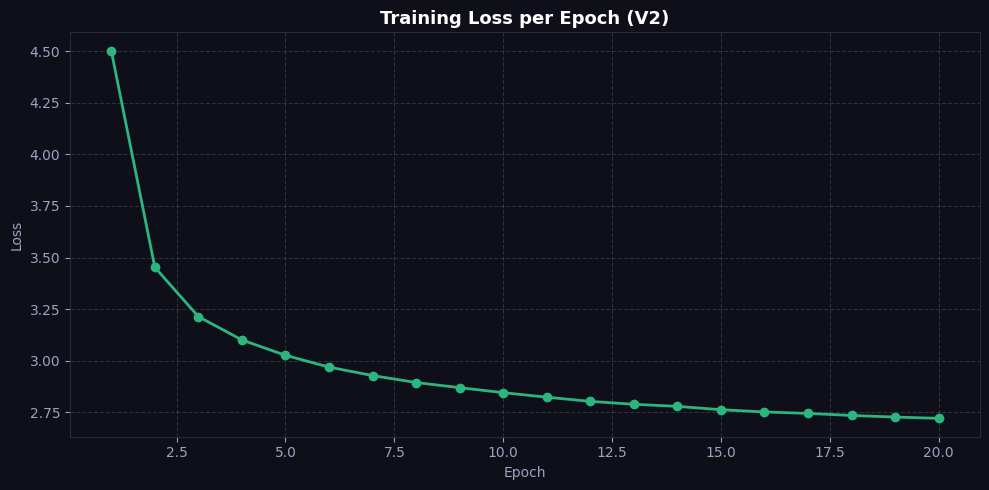

In [11]:
all_losses = history_v2.history['loss']

fig, ax = plt.subplots(figsize=(10, 5))

fig.patch.set_facecolor('#0f0f1a')
ax.set_facecolor('#0f0f1a')


ax.plot(range(1, 1 + len(all_losses)),
        all_losses,
        marker='o',
        color='#2cb67d',   
        linewidth=2)

ax.set_title("Training Loss per Epoch (V2)",
             color='white', fontsize=13, fontweight='bold')

ax.set_xlabel("Epoch", color='#a0a0c0')
ax.set_ylabel("Loss", color='#a0a0c0')


ax.tick_params(colors='#a0a0c0')


for spine in ax.spines.values():
    spine.set_edgecolor('#2a2a3a')


ax.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()

plt.savefig("loss_curve_v2_styled.png", facecolor=fig.get_facecolor())
plt.show()



In [12]:
model_v2.save("model_v2_final.keras")
print("Model saved")

pickle.dump(features, open("features.pkl", "wb"))
print("Features saved")


pickle.dump(word_to_idx, open("word_to_idx.pkl", "wb"))
pickle.dump(idx_to_word, open("idx_to_word.pkl", "wb"))
print("Vocabulary saved")


pickle.dump(train_captions, open("train_captions.pkl", "wb"))
pickle.dump(test_captions, open("test_captions.pkl", "wb"))
print("Captions saved")


config = {
    'vocab_size': vocab_size,
    'max_len': max_len,
    'embed_dim': 200
}
pickle.dump(config, open("config.pkl", "wb"))
print("Config saved")

print("\nAll files saved to Kaggle output!")

Model saved
Features saved
Vocabulary saved
Captions saved
Config saved

All files saved to Kaggle output!


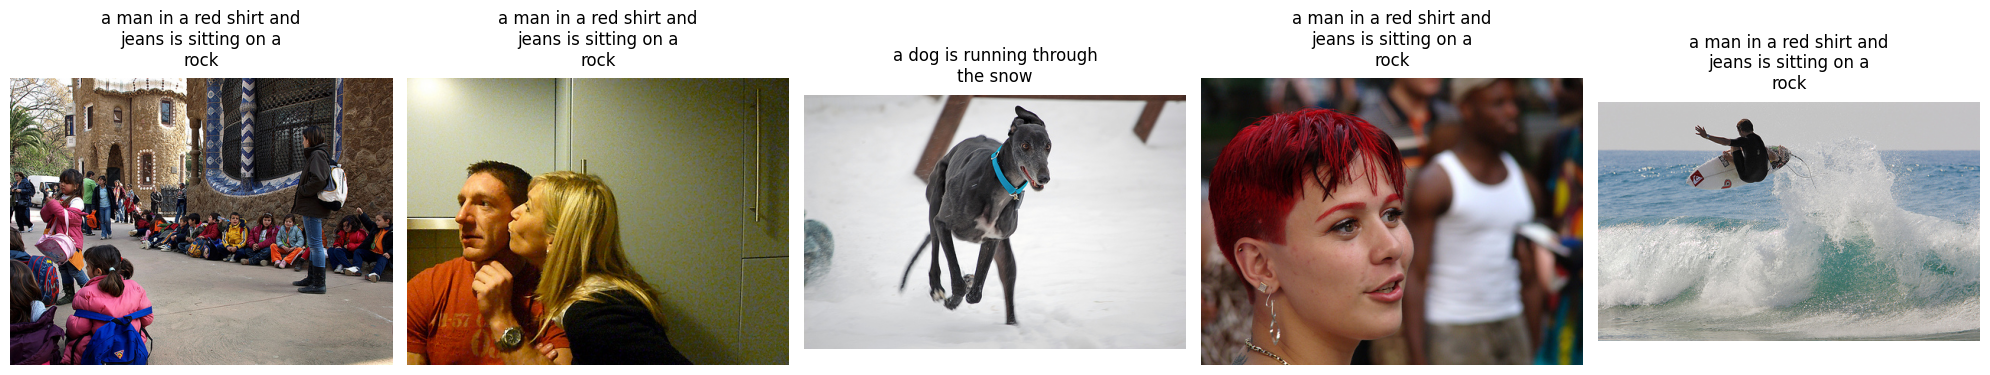

Done!


In [13]:
def generate_caption(model, feature, word_to_idx, idx_to_word, max_len):
    caption = "startseq"
    for _ in range(max_len):
        seq       = [word_to_idx.get(w, 0) for w in caption.split()]
        seq       = pad_sequences([seq], maxlen=max_len)
        pred      = model.predict([feature, seq], verbose=0)
        next_idx  = np.argmax(pred)
        next_word = idx_to_word.get(next_idx, "")
        if next_word == "endseq" or not next_word:
            break
        caption += " " + next_word
    return caption.replace("startseq", "").strip()

img_dir      = "/kaggle/input/datasets/adityajn105/flickr8k/Images"
sample_images = list(test_captions.keys())[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 6))  # ← taller figure

for i, img_name in enumerate(sample_images):
    feature = features[img_name]
    caption = generate_caption(model_v2, feature, word_to_idx, idx_to_word, max_len)

    img = Image.open(f"{img_dir}/{img_name}")
    axes[i].imshow(img)
    axes[i].axis("off")

    # Wrap long captions cleanly
    import textwrap
    wrapped = "\n".join(textwrap.wrap(caption, width=25))
    axes[i].set_title(wrapped, fontsize=12, pad=10)

plt.tight_layout()
plt.savefig("captions_v2_output.png", bbox_inches='tight')
plt.show()
print("Done!")

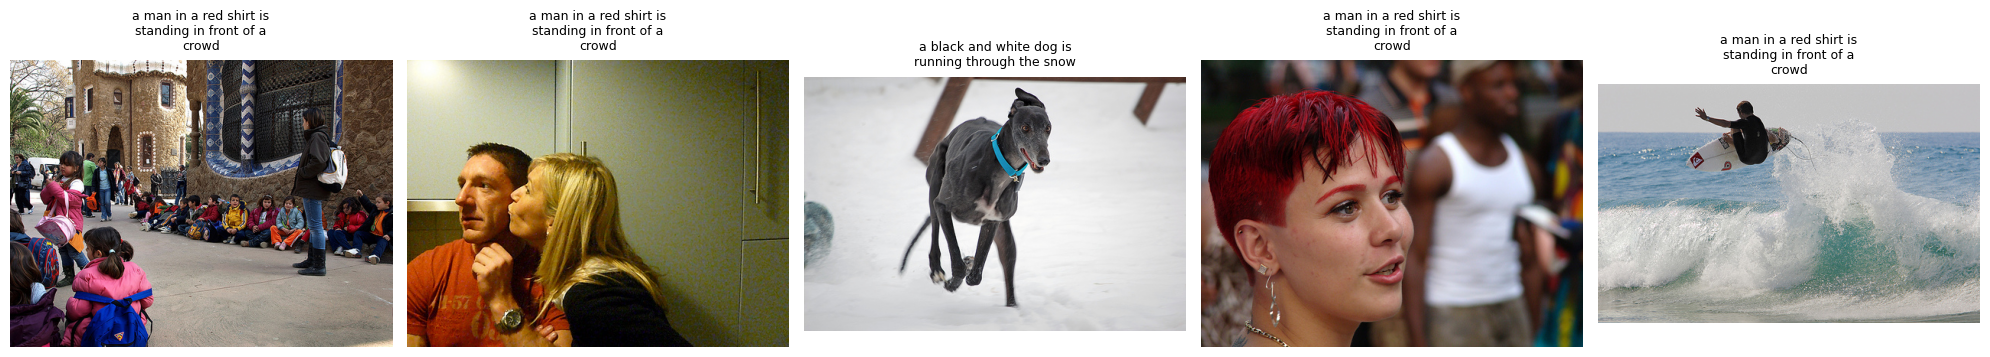

Done!


In [14]:
def beam_search_caption(model, feature, word_to_idx, idx_to_word, max_len, beam_width=5):
    # Start with startseq
    sequences = [([word_to_idx.get('startseq', 0)], 0.0)]
    
    for _ in range(max_len):
        candidates = []
        for seq, score in sequences:
            if idx_to_word.get(seq[-1], '') == 'endseq':
                candidates.append((seq, score))
                continue
            padded = pad_sequences([seq], maxlen=max_len)
            preds  = model.predict([feature, padded], verbose=0)[0]
            top_k  = np.argsort(preds)[-beam_width:]
            for idx in top_k:
                new_seq   = seq + [idx]
                new_score = score - np.log(preds[idx] + 1e-10)
                candidates.append((new_seq, new_score))
        sequences = sorted(candidates, key=lambda x: x[1])[:beam_width]

    best_seq = sequences[0][0]
    caption  = ' '.join(idx_to_word.get(i, '') for i in best_seq)
    caption  = caption.replace('startseq', '').replace('endseq', '').strip()
    return caption

# Test on same 5 images
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
import textwrap

for i, img_name in enumerate(sample_images):
    feature = features[img_name]
    caption = beam_search_caption(model_v2, feature, word_to_idx, idx_to_word, max_len, beam_width=5)

    img     = Image.open(f"{img_dir}/{img_name}")
    axes[i].imshow(img)
    axes[i].axis("off")
    wrapped = "\n".join(textwrap.wrap(caption, width=25))
    axes[i].set_title(wrapped, fontsize=9, pad=8)

plt.tight_layout()
plt.savefig("captions_beam_search.png")
plt.show()
print("Done!")

The issue with version 1 is: 

1. Weak Image–Text Fusion
2. Image Feature Used Only Once
3. No Attention Mechanism
4. LSTM Stack is Shallow
5. Embedding is Random
6. No Regularization on Output